A set of simulations & hypothesis tests for assessing the statistical power of "minP vs CRE of interest" tests in the shendure dataset...

Essentially a better version of `power_shendure_vs_minp.ipynb` with a more representative distribution of positive and negative effects. Specifically, we will be using the real values, plus many negatives.

Based on UKBB paper, expect ~30% of library to be active. So we will add 2x original size of negatives... 

We will also reduce computational burden by producing half-orthos.

# Imports & dask cluster creation

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
from pathlib import Path

%load_ext autoreload
%autoreload 2

2026-02-01 10:17:47.053647: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-01 10:17:47.057636: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [2]:
local=True
if local:
    cluster=LocalCluster(memory_limit='48G')
    client=Client(cluster)
else:
    cluster=SLURMCluster(
        cores=2,#cores per slurm job
        memory="16G",#memory per slurm job
        processes=1,#dask workers per slurm job,
        job_extra_directives=["-p day", 
            f"--job-name=simclust_worker",
            f"--time=6:00:00",
            f"--output=worker_%j.out"]
    )
    #cluster.scale(jobs=20)
    cluster.scale(jobs=20)
    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )

2026-02-01 10:17:50,719 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 48G due to system memory limit of 16.00 GiB
2026-02-01 10:17:50,721 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 48G due to system memory limit of 16.00 GiB


In [3]:
data_root=Path("/nfs/roberts/project/pi_skr2/shared/tabula_data")

In [4]:
client.dashboard_link

'http://127.0.0.1:8787/status'

# Ground truth creation

We will use parameter estimates averaged across cell-type nd cre models. 

The shendure dataset is characterized by extremely heterogenious transfection, so different sets of CREs are represented in different cell types, likely due to differential clonotype contribution to different cell-types. For this reason, we don't have ground truth values for many combinations of cre_id, cell type. This means that direct simulation runs into problems, since it allows transfection of any cre into any cell type...

See commit `58a65def6964cea9247c15937dd60714489f1750` and 2026-10-23 and 2026-01-29 notes for further discussion.

In [ ]:
primordial=scm.ortho.load(client,data_root/"shendure","shendure_ortho_20260306")
primordial.compute_model_qc()

We use by_cell_type models, expecting that they will have more robust estimates...

In [ ]:
import pandas as pd
import numpy as np

vals=[]
for key in primordial.by_cell_qc.keys():
    working=primordial.by_cell_qc[key]['dat'].reset_index().drop(columns=["mean(umis_mpra_bc)"])
    working["cell_type"]=key
    vals.append(working)
gt_cell_type=pd.concat(vals)

In [ ]:
#casting away from sparse, since it's not sparse anymore
gt_cell_type["mu"] = gt_cell_type["mu"].astype(float)

#this doesn't even work
gt_cell_type["cre_id"]=gt_cell_type["cre_id"].astype(str)
gt_cell_type["cell_type"]=gt_cell_type["cell_type"].astype(str)

In [ ]:
gt_cell_type

In [ ]:
combo_counts=gt_cell_type[gt_cell_type["cre_id"]!="reference"].drop(columns=["mu"]).groupby("cell_type").nunique()
max_tfection=max(combo_counts["cre_id"])
combo_counts

Next, remove the cell-type-specific reference values.

In [ ]:
gt_cell_type=gt_cell_type[gt_cell_type["cre_id"]!="reference"]

Now, we all identifying information, just making generic strength values...

In [ ]:
real_means=gt_cell_type.drop(columns=["cre_id","cell_type"])
real_means

In [ ]:
num_cell_types=len(gt_cell_type["cell_type"].unique())

In [ ]:
num_cell_types

In [ ]:
synth_cre_names=[f"synthcre_{i}" for i in range(0,len(real_means))]

parts=[]
for i in range(0,num_cell_types):
    working=real_means.sample(frac=1)
    working["cre_id"]=synth_cre_names
    working["cell_type"]=f"ct_{i}"
    parts.append(working)

cartesian=pd.concat(parts).sample(frac=1).reset_index(drop=True)
cartesian

In [ ]:
#make 70% inactive
minP=scm.SHENDURE_BOUNDS.reference_activity
num_inactive=int(len(cartesian)*0.7)
cartesian.loc[cartesian.index[:num_inactive],"mu"]=minP
cartesian


In [ ]:
#now we pick max_tfection CREs to proceed with, because this is the number of unique cre_id 
#found in the the cell type with the most unique CRE ids (reference, or PSC, in shend)

chosen_cre_id=np.random.choice(cartesian["cre_id"].unique(),max_tfection,replace=False)
sampled_nbs=cartesian[cartesian["cre_id"].isin(chosen_cre_id)]
sampled_nbs


add universal reference CRE

In [ ]:
ref_df=pd.DataFrame({"cell_type":[f"ct_{i}" for i in range(0,num_cell_types)]})
ref_df["mu"]=minP
ref_df["cre_id"]="reference"
ref_df


Stack & make one of the celltypes reference...

In [ ]:
final_gt=pd.concat([ref_df,sampled_nbs])
final_gt["cell_type"]=final_gt["cell_type"].replace({"ct_0":"reference"})
final_gt

# Creating artificial libraries

In [ ]:
libraries=[scm.simulate_library(CREs=final_gt["cre_id"],
                 library_model=scm.SHENDURE_BOUNDS.library_model)
                 for i in range(5)]

# Creating sim

Create some bounds to simulate from. These will be identical to the normal shendure bounds, except that we simplify to just one cell-type...

In [ ]:
bound=scm.SHENDURE_BOUNDS.copy()

In [ ]:
print(bound.cells_per_cell_type.name)
print(bound.cells_per_cell_type.index.name)
s=bound.cells_per_cell_type
s

In [ ]:
s.index=[f"ct_{i}" for i in range(1,num_cell_types)]+["reference"]
s

In [ ]:
bound.cells_per_cell_type=s

In [ ]:
sim=scm.de_novo_simulation(location=data_root,
                            name="twothird_pow_sim_2026-01-30",
                            client=client,
                            libraries=libraries,
                            library_mapping="corresponding",
                            flatten_overtransfection=False,
                            n_sims=5,
                            experiment_bounds=bound,
                            ground_truth=final_gt)

In [ ]:
sim.gamut()

In [ ]:
sim.save()

# Fit orthos

In [ ]:
sim=scm.de_novo_simulation(location=data_root,
                            name="twothird_pow_sim_2026-01-30",
                            client=client)

In [ ]:
any(sim.ground_truth["cre_id"].unique()=="reference")

In [ ]:
sim.fit_orthos(serial_orthos=True)

In [ ]:
sim

In [ ]:
x.operations

In [ ]:
sim.save()

In [ ]:
print("DONE")

# Wald precompute

In [ ]:
sim=scm.de_novo_simulation(location=data_root,
                            name="twothird_pow_sim_2026-01-30",
                            client=client)

In [ ]:
sim.precompute_wald(cov_method="opg")
sim.precompute_wald(cov_method="sandwich")

In [ ]:
sim.save()

In [ ]:
sim.precompute_wald(cov_method="opg")

In [ ]:
sim.save()

# Hypothesis testing

## Add the hypotheses...

In [ ]:
sim=scm.de_novo_simulation(location=data_root,
                            name="twothird_pow_sim_2026-01-30",
                            client=client)

In [ ]:
example_data=scm.scMPRA_data.from_parquet(sim.scmpradatp/"0.scmpra")

In [ ]:
example_data

In [ ]:
hs_all_ct = scm.make_all_by_celltype_hypotheses(
    counts=example_data,
    reference_cre="reference",
)

In [ ]:
hs_all_ct.df

In [ ]:
sim.add_hypothesis_set("hs_all_ct",hs_all_ct)
sim.save()

## Run tests

In [5]:
sim=scm.de_novo_simulation(location=data_root,
                            name="twothird_pow_sim_2026-01-30",
                            client=client)

scMPRAforge: INFO: 'state.parquet' found for 'twothird_pow_sim_2026-01-30', loading.


In [ ]:
sim.wald("hs_all_ct")

In [ ]:
sim.wald("hs_all_ct",cov_method="opg")

In [ ]:
sim.mwu("hs_all_ct")

In [ ]:
sim.save()

## Performance metrics

In [ ]:
sim=scm.de_novo_simulation(location=data_root,
                            name="twothird_pow_sim_2026-01-30",
                            client=client)

In [11]:
sim._all_classifier_summary("hs_all_ct")

scMPRAforge: INFO: Dropped 48 or 2.3% of tests with NA values for test:wald_opg, rep:0.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_opg, rep:1.
scMPRAforge: INFO: Dropped 36 or 1.7% of tests with NA values for test:wald_opg, rep:2.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_opg, rep:3.
scMPRAforge: INFO: Dropped 35 or 1.7% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 48 or 2.3% of tests with NA values for test:wald_sandwich, rep:0.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_sandwich, rep:1.
scMPRAforge: INFO: Dropped 36 or 1.7% of tests with NA values for test:wald_sandwich, rep:2.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_sandwich, rep:3.
scMPRAforge: INFO: Dropped 35 or 1.7% of tests with NA values for test:wald_sandwich, rep:4.


,replicate,auroc,auprc,test
0,0,0.910177,0.899572,mwu
1,1,0.897130,0.890072,mwu
2,2,0.893607,0.889984,mwu
3,3,0.922797,0.913330,mwu
4,4,0.879193,0.871824,mwu
0,0,0.912851,0.903917,wald_opg
1,1,0.897494,0.890825,wald_opg
2,2,0.898382,0.895601,wald_opg
3,3,0.924995,0.917680,wald_opg
4,4,0.881860,0.879063,wald_opg


scMPRAforge: INFO: Dropped 48 or 2.3% of tests with NA values for test:wald_opg, rep:0.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_opg, rep:1.
scMPRAforge: INFO: Dropped 36 or 1.7% of tests with NA values for test:wald_opg, rep:2.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_opg, rep:3.
scMPRAforge: INFO: Dropped 35 or 1.7% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 48 or 2.3% of tests with NA values for test:wald_sandwich, rep:0.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_sandwich, rep:1.
scMPRAforge: INFO: Dropped 36 or 1.7% of tests with NA values for test:wald_sandwich, rep:2.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_sandwich, rep:3.
scMPRAforge: INFO: Dropped 35 or 1.7% of tests with NA values for test:wald_sandwich, rep:4.


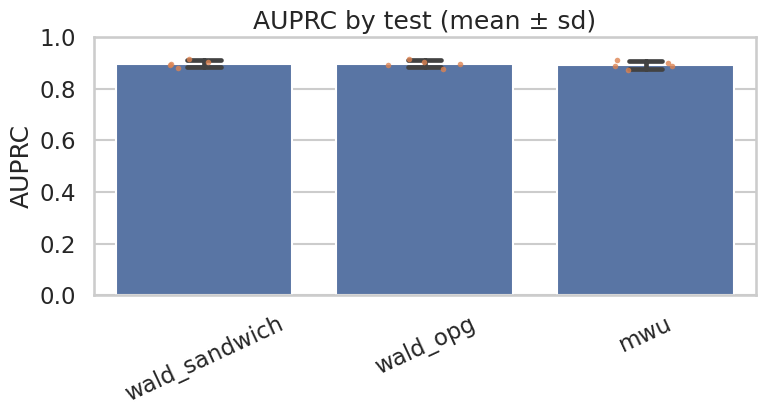

In [12]:
sim.performance_barchart("hs_all_ct","auprc")

scMPRAforge: INFO: Dropped 48 or 2.3% of tests with NA values for test:wald_opg, rep:0.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_opg, rep:1.
scMPRAforge: INFO: Dropped 36 or 1.7% of tests with NA values for test:wald_opg, rep:2.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_opg, rep:3.
scMPRAforge: INFO: Dropped 35 or 1.7% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 48 or 2.3% of tests with NA values for test:wald_sandwich, rep:0.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_sandwich, rep:1.
scMPRAforge: INFO: Dropped 36 or 1.7% of tests with NA values for test:wald_sandwich, rep:2.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_sandwich, rep:3.
scMPRAforge: INFO: Dropped 35 or 1.7% of tests with NA values for test:wald_sandwich, rep:4.


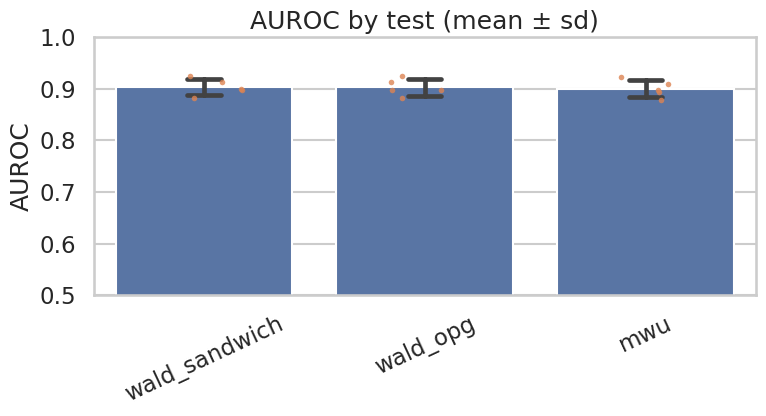

In [13]:
sim.performance_barchart("hs_all_ct","auroc")

scMPRAforge: INFO: Dropped 48 or 2.3% of tests with NA values for test:wald_opg, rep:0.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_opg, rep:1.
scMPRAforge: INFO: Dropped 36 or 1.7% of tests with NA values for test:wald_opg, rep:2.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_opg, rep:3.
scMPRAforge: INFO: Dropped 35 or 1.7% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 48 or 2.3% of tests with NA values for test:wald_sandwich, rep:0.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_sandwich, rep:1.
scMPRAforge: INFO: Dropped 36 or 1.7% of tests with NA values for test:wald_sandwich, rep:2.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_sandwich, rep:3.
scMPRAforge: INFO: Dropped 35 or 1.7% of tests with NA values for test:wald_sandwich, rep:4.


Called positive: 576 / 2060 (27.9612%)
Called positive: 592 / 2024 (29.2490%)
Called positive: 596 / 2024 (29.4466%)


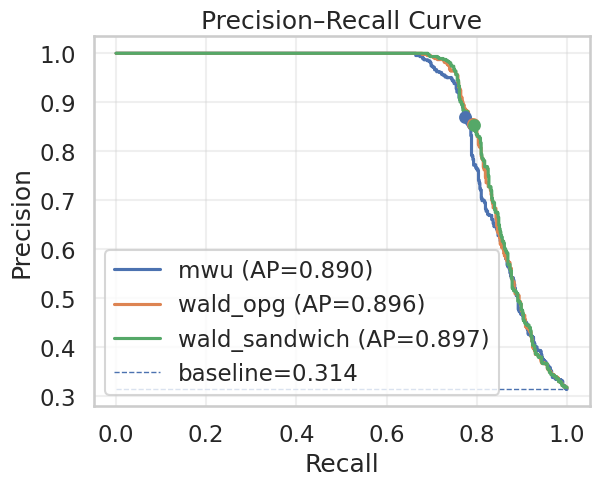

In [15]:
sim.median_performance_curve(hypothesis_set_name="hs_all_ct",performance_type="PRC")

scMPRAforge: INFO: Dropped 48 or 2.3% of tests with NA values for test:wald_opg, rep:0.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_opg, rep:1.
scMPRAforge: INFO: Dropped 36 or 1.7% of tests with NA values for test:wald_opg, rep:2.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_opg, rep:3.
scMPRAforge: INFO: Dropped 35 or 1.7% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 48 or 2.3% of tests with NA values for test:wald_sandwich, rep:0.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_sandwich, rep:1.
scMPRAforge: INFO: Dropped 36 or 1.7% of tests with NA values for test:wald_sandwich, rep:2.
scMPRAforge: INFO: Dropped 49 or 2.4% of tests with NA values for test:wald_sandwich, rep:3.
scMPRAforge: INFO: Dropped 35 or 1.7% of tests with NA values for test:wald_sandwich, rep:4.


Called positive: 576 / 2060 (27.9612%)
Called positive: 592 / 2024 (29.2490%)
Called positive: 596 / 2024 (29.4466%)


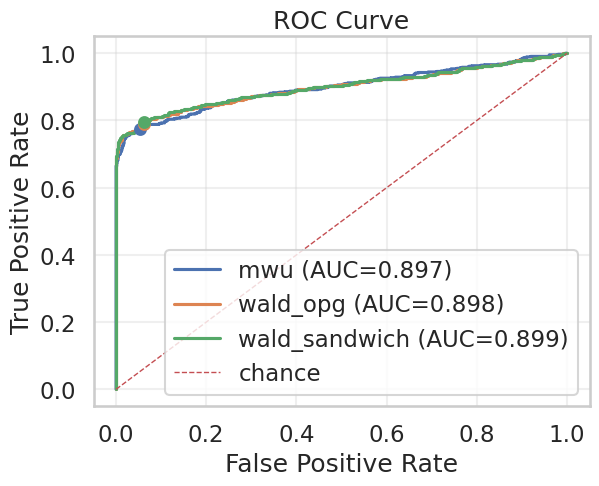

In [16]:
sim.median_performance_curve(hypothesis_set_name="hs_all_ct",performance_type="ROC")

# Close the cluster

In [12]:
client.close()
cluster.close()